실습 4. 두 센서 복원과 전후 비교
- 두 센서를 시간 보간으로 복원하고 채운 자리를 표시해 비교

목표
- 두 센서를 시간 보간으로 복원하고 채운 자리를 표시해 전후 비교

단계
- 두 센서의 복원 전 결측 개수를 확인
- 시간 보간으로 두 센서를 함께 복원
- 채운 자리를 표시한 전후 그래프로 비교

예상 결과
- 복원 전 각 22칸 결측, 복원 후 0; 채운 자리가 그래프에 표시

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('../data/22_열처리.csv', encoding='utf-8')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()
norm = df[['제어출력', '소입로온도']].asfreq('10s')

복원 전: {'제어출력': 22, '소입로온도': 22}
복원 후: {'제어출력': 0, '소입로온도': 0}


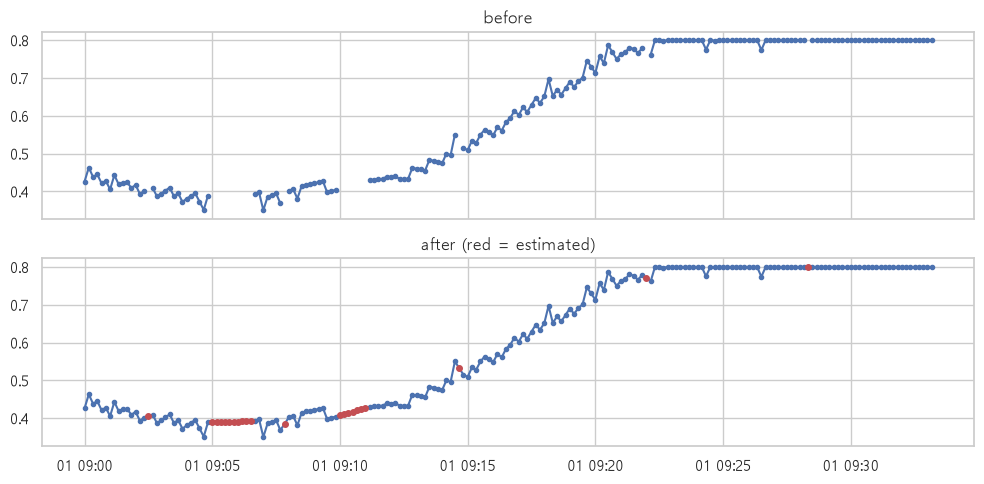

In [ ]:
# [다중 센서 일괄 보간 및 차트상 보간 데이터(Estimated) 하이라이트 시각화]
# 1. norm.interpolate(method='time'): 데이터프레임 내 모든 센서 컬럼의 누락값을 시간 보간법으로 일시에 수복합니다.
# 2. was_na: 보간 전에 결측 상태였던 행들을 불리언 시리즈 형태로 기억합니다.
# 3. ax[1].plot(..., 'ro'): 보간 후 복원된 시리즈 위에 원래 NaN이었던 포인트만 빨간 동그라미(Red Circle) 마커로 포개어 그립니다.
# * 작업자에게 보간을 통해 보정 완료된 기계 온도 그래프를 보여줄 때,
#   "어떤 값이 실제 측정치이고 어떤 값이 시스템이 추정한 보간치인가"를 명확하게 구분해 시각 보고서로 제출합니다.
# * markersize 값을 적절히 조율하여 원본 플롯 라인 뒤의 점들이 시인성 높게 표출되도록 제어해야 합니다.

print('복원 전:', norm.isna().sum().to_dict())
# 복원 전: {'제어출력': 22, '소입로온도': 22}
restored = norm.interpolate(method='time')

print('복원 후:', restored.isna().sum().to_dict())
# 복원 후: {'제어출력': 0, '소입로온도': 0}
was_na = norm['제어출력'].isna()

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(norm.index, norm['제어출력'], marker='.'); ax[0].set_title('before')
ax[1].plot(restored.index, restored['제어출력'], marker='.')

ax[1].plot(restored.index[was_na], restored['제어출력'][was_na], 'ro', markersize=4)
ax[1].set_title('after (red = estimated)'); plt.tight_layout()

plt.show()